## **K-Fold Cross Validation**

É uma técnica que permite estimar o erro de generalização de um modelo a partir de múltiplas divisões do conjunto de dados disponíveis.

### **Fundamentação**

Seja $\mathcal{D}$ o conjunto de dados observados:

$$
\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}
$$

Vamos dividir $\mathcal{D}$ em $K$ subconjuntos (**folds**) de mesmo tamanho:
$$
\{\mathcal{F}_i\}_{i=1}^{K}
$$

tal que

*   $\mathcal{F}_{i} \neq \emptyset \quad \forall i \leq K $
*   $|\mathcal{F}_{1}| = |\mathcal{F}_{2}| = \dots = |\mathcal{F}_{T}|$

*   $\mathcal{F}_{i} \cap \mathcal{F}_{j} = \emptyset \quad \forall i \neq j$
*   $\displaystyle\bigcup_{i = 1}^{K} \mathcal{F}_{i} = \mathcal{D}$

### **Partições de Treino e de Validação**

Vamos realizar $K$ experimentos onde no experimento $j$:

##### **Conjunto de validação:**

$$
\mathcal{D}^{(j)}_{val} = \mathcal{F}_j
$$

##### **Conjunto de treino:**

$$
\mathcal{D}^{(j)}_{train} = \mathcal{D} \setminus \mathcal{F}_j
$$

### **Erro em cada Fold**

Seja uma função de perda geral:

$$
\mathcal{L} : \mathcal{Y} \times \mathcal{Y} \rightarrow \mathbb{R}
$$

Onde $\mathcal{L}(y, \hat{y})$ mede o erro entre o valor real $y$ e a predição $\hat{y}$.

No $j$-ésimo experimento, treinamos um modelo:

$$
\hat{f}^{(j)} : \mathcal{X} \rightarrow \mathcal{Y}
$$

utilizando o conjunto $\mathcal{D}^{(j)}_{train}$.

O erro no fold $j$ é definido como a média da perda no conjunto de validação:

$$
\varepsilon_j = \dfrac{1}{|\mathcal{D}^{(j)}_{val}|} \sum_{\mathbf{x}_i, y_i \in \mathcal{D}^{(j)}_{val}} \mathcal{L}(y_i, \hat{f}^{(j)}(\mathbf{x}_i))
$$

### **Erro Médio (Estimativa do Erro de Generalização)**


Após os $K$ experimentos, obtemos os erros:

$$
\{\varepsilon_1, \varepsilon_2, \varepsilon_3, \dots, \varepsilon_K\}
$$

A estimativa do erro de generalização é dada pela média:

$$
\bar{\varepsilon} = \dfrac{1}{K}\sum_{j=1}^{K} \varepsilon_j
$$

### **Variância da Estimativa (Estabilidade do Modelo)**

A **variabilidade** do modelo é dada por:

$$
Var({\varepsilon}) = \dfrac{1}{K}\sum_{j=1}^{K} (\varepsilon_j - \bar{\varepsilon})^{2}
$$

e o desvio padrão:

$$
\sigma_{\varepsilon} = \sqrt{Var(\varepsilon)}
$$

### **Função de perda $\mathcal{L}(.,.)$**

A função $\mathcal{L}(.,.)$ depende do tipo de tarefa realizada pelo modelo.

#### **Classificação**

Em problemas de **classificação**, uma escolha comum é a **0-1 Loss**:

$$
\mathcal{L}(y, \hat{y}) =
\begin{cases}
0, & \text{se } y = \hat{y} \\
1, & \text{se } y \neq \hat{y}
\end{cases}$$

#### **Regressão**

Em problemas de **regressão**, uma escolha comum é a **Quadratic Loss**:

$$
\mathcal{L}(y, \hat{y}) = (\hat{y} - y)^{2}
$$

## **Comparação entre Modelos para Classificação**

Nessa prática, vamos usar os algoritmos usados em classificação já estudados:

*   **K-Nearest Neighbors (KNN)**
*   **Regressão Logística**
*   **Neive Bayes**
*   **Decision Tree**
*   **Random Forest**

E usando K-Fold Crosso Validation, comparar cada um usando as métricas estudadas.

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import cross_validate

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [59]:
k_to_KNN = 3

models = {
    f"KNN (K = {k_to_KNN})": KNeighborsClassifier(n_neighbors=k_to_KNN),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier()
}

In [60]:
from sklearn.model_selection import StratifiedKFold

def folds(K):
  skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
  return skf

def zero_one_loss(y_real, y_pred):
    return np.array([0 if y == y_hat else 1 for y, y_hat in zip(y_real, y_pred)])

In [61]:
def cross_validation(model, number_folds, X, y):

  skf = StratifiedKFold(n_splits=number_folds, shuffle=True, random_state=42)

  fold_errors = []

  for train_idx, test_idx in skf.split(X, y):

      X_train, y_train = X[train_idx], y[train_idx]
      X_test,  y_test  = X[test_idx],  y[test_idx]

      model.fit(X_train, y_train)
      y_pred = model.predict(X_test)

      losses = zero_one_loss(y_test, y_pred)
      R_j    = (1 / len(y_test)) * np.sum(losses)

      fold_errors.append(R_j)

  error_mean = np.mean(fold_errors)
  std  = np.std(fold_errors)

  return error_mean, std

In [62]:
results = []

for name, model in models.items():
    error_mean, std = cross_validation(model, number_folds=5, X=X, y=y)
    results.append({"Model": name, "Error Mean": error_mean, "Error Std": std})

In [63]:
df_results = pd.DataFrame(results)
df_results.sort_values(by="Error Mean")

,Model,Error Mean,Error Std
1,Logistic Regression,0.033333,0.029814
0,KNN (K = 3),0.046667,0.049889
3,Decision Tree,0.046667,0.033993
4,Random Forest,0.046667,0.033993
2,Gaussian Naive Bayes,0.053333,0.040000


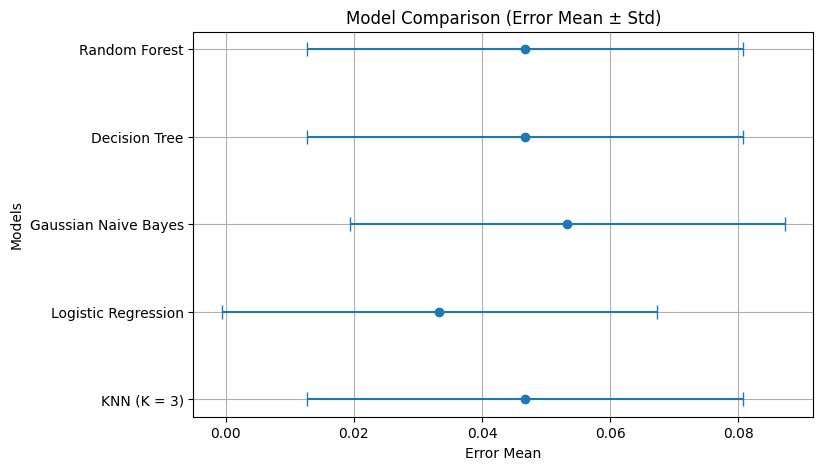

In [64]:
models = [r["Model"] for r in results]
error_mean = [r["Error Mean"] for r in results]

y_pos = range(len(models))

plt.figure(figsize=(8,5))

plt.errorbar(
    error_mean,
    y_pos,
    xerr=std,
    fmt='o',
    capsize=5
)

plt.yticks(y_pos, models)
plt.xlabel("Error Mean")
plt.ylabel("Models")
plt.title("Model Comparison (Error Mean ± Std)")

plt.grid(True)

plt.show()